# Bloque 1: Análisis EDA con PySpark

Para el desarrollo de este proyecto se seleccionó la base de datos de resultados unicos de la prueba Saber 11, filtrando el cargue de los registros por el año 2019 y area urbana.

El dataset cuenta con 924.826 registros y un total de 51 columnas.

Se seleccionó esta base de datos con dichos filtros, ya que en el año 2019 presente mi ICFES saber 11. Se quiere analizar como las condiciones estructurales, ya sea bajo condiciones familiares y algunas caracteristicas institucionales, se pueden relacionar con el desempeño academico evaluado en el Saber 11. 

## 1. Inicialización PySpark

In [4]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count, when, isnan

spark = SparkSession.builder \
    .appName("bloque1_eda_Pedraza") \
    .getOrCreate()

spark

## 2. Cargue de la base

In [5]:
ruta = "C:/Users/luisa/OneDrive/Documentos/proyecto_final_JosuePedraza/datos/Resultados_únicos_Saber_11_20260525.csv"

df = spark.read.csv(
    ruta,
    header=True,
    inferSchema=True,
    sep=","
)

## 3. Seleccion de variables

Aquí se eliminaran algunas variables que pueden generar ruido, ya que hay muchas variables que son codigos de ubicacion y caracteristicas de las instituciones que no tienen tanta relevancia conceptual con el objetivo de estudio.

In [6]:
columnas_usar = [

    # Contexto educativo
    'COLE_BILINGUE',
    'COLE_CALENDARIO',
    'COLE_JORNADA',
    'COLE_NATURALEZA',

    # Contexto estructural
    'ESTU_GENERO',
    'FAMI_CUARTOSHOGAR',
    'FAMI_EDUCACIONMADRE',
    'FAMI_EDUCACIONPADRE',
    'FAMI_ESTRATOVIVIENDA',
    'FAMI_PERSONASHOGAR',
    'FAMI_TIENEAUTOMOVIL',
    'FAMI_TIENECOMPUTADOR',
    'FAMI_TIENEINTERNET',
    'FAMI_TIENELAVADORA',

    # Desempeño académico
    'PUNT_INGLES',
    'PUNT_MATEMATICAS',
    'PUNT_SOCIALES_CIUDADANAS',
    'PUNT_C_NATURALES',
    'PUNT_LECTURA_CRITICA',
    'PUNT_GLOBAL'
]
df_clean = df.select(columnas_usar)

In [7]:
print("Número de filas:", df_clean.count())
print("Número de columnas:", len(df_clean.columns))

Número de filas: 924826
Número de columnas: 20


In [8]:
df_clean.printSchema()

root
 |-- COLE_BILINGUE: string (nullable = true)
 |-- COLE_CALENDARIO: string (nullable = true)
 |-- COLE_JORNADA: string (nullable = true)
 |-- COLE_NATURALEZA: string (nullable = true)
 |-- ESTU_GENERO: string (nullable = true)
 |-- FAMI_CUARTOSHOGAR: string (nullable = true)
 |-- FAMI_EDUCACIONMADRE: string (nullable = true)
 |-- FAMI_EDUCACIONPADRE: string (nullable = true)
 |-- FAMI_ESTRATOVIVIENDA: string (nullable = true)
 |-- FAMI_PERSONASHOGAR: string (nullable = true)
 |-- FAMI_TIENEAUTOMOVIL: string (nullable = true)
 |-- FAMI_TIENECOMPUTADOR: string (nullable = true)
 |-- FAMI_TIENEINTERNET: string (nullable = true)
 |-- FAMI_TIENELAVADORA: string (nullable = true)
 |-- PUNT_INGLES: integer (nullable = true)
 |-- PUNT_MATEMATICAS: integer (nullable = true)
 |-- PUNT_SOCIALES_CIUDADANAS: integer (nullable = true)
 |-- PUNT_C_NATURALES: integer (nullable = true)
 |-- PUNT_LECTURA_CRITICA: integer (nullable = true)
 |-- PUNT_GLOBAL: integer (nullable = true)



In [9]:
df_clean.show(5)

+-------------+---------------+------------+---------------+-----------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|COLE_BILINGUE|COLE_CALENDARIO|COLE_JORNADA|COLE_NATURALEZA|ESTU_GENERO|FAMI_CUARTOSHOGAR| FAMI_EDUCACIONMADRE| FAMI_EDUCACIONPADRE|FAMI_ESTRATOVIVIENDA|FAMI_PERSONASHOGAR|FAMI_TIENEAUTOMOVIL|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|FAMI_TIENELAVADORA|PUNT_INGLES|PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|PUNT_GLOBAL|
+-------------+---------------+------------+---------------+-----------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-----------+----------------+--------

## 4. Estadística descriptiva

### 4.1 Resumen de los datos

In [10]:
df_clean.summary().show()

+-------+-------------+---------------+------------+---------------+-----------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+------------------+
|summary|COLE_BILINGUE|COLE_CALENDARIO|COLE_JORNADA|COLE_NATURALEZA|ESTU_GENERO|FAMI_CUARTOSHOGAR| FAMI_EDUCACIONMADRE| FAMI_EDUCACIONPADRE|FAMI_ESTRATOVIVIENDA|FAMI_PERSONASHOGAR|FAMI_TIENEAUTOMOVIL|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|FAMI_TIENELAVADORA|       PUNT_INGLES|  PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|  PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|       PUNT_GLOBAL|
+-------+-------------+---------------+------------+---------------+-----------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+---------------

In [11]:
df_clean.describe().show()

+-------+-------------+---------------+------------+---------------+-----------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+------------------+------------------+------------------------+------------------+--------------------+------------------+
|summary|COLE_BILINGUE|COLE_CALENDARIO|COLE_JORNADA|COLE_NATURALEZA|ESTU_GENERO|FAMI_CUARTOSHOGAR| FAMI_EDUCACIONMADRE| FAMI_EDUCACIONPADRE|FAMI_ESTRATOVIVIENDA|FAMI_PERSONASHOGAR|FAMI_TIENEAUTOMOVIL|FAMI_TIENECOMPUTADOR|FAMI_TIENEINTERNET|FAMI_TIENELAVADORA|       PUNT_INGLES|  PUNT_MATEMATICAS|PUNT_SOCIALES_CIUDADANAS|  PUNT_C_NATURALES|PUNT_LECTURA_CRITICA|       PUNT_GLOBAL|
+-------+-------------+---------------+------------+---------------+-----------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+---------------

### 4.2 Percentiles

In [12]:
variables_puntajes = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA",
    "PUNT_GLOBAL"
]

percentiles = df_clean.approxQuantile(
    variables_puntajes,
    [0.25, 0.5, 0.75],
    0.01
)

import pandas as pd

tabla_percentiles = pd.DataFrame(
    [
        [var, vals[0], vals[1], vals[2]]
        for var, vals in zip(variables_puntajes, percentiles)
    ],
    columns=["Variable", "Q1_25%", "Mediana_50%", "Q3_75%"]
)

tabla_percentiles

,Variable,Q1_25%,Mediana_50%,Q3_75%
0,PUNT_INGLES,40.0,49.0,57.0
1,PUNT_MATEMATICAS,43.0,51.0,60.0
2,PUNT_SOCIALES_CIUDADANAS,38.0,46.0,56.0
3,PUNT_C_NATURALES,41.0,48.0,56.0
4,PUNT_LECTURA_CRITICA,46.0,53.0,60.0
5,PUNT_GLOBAL,211.0,247.0,285.0


### 4.3 Conteos por categoría

In [13]:
df_clean.groupBy("ESTU_GENERO").count().show()
df_clean.groupBy("FAMI_ESTRATOVIVIENDA").count().show()
df_clean.groupBy("FAMI_TIENEINTERNET").count().show()
df_clean.groupBy("COLE_NATURALEZA").count().show()

+-----------+------+
|ESTU_GENERO| count|
+-----------+------+
|          F|503126|
|       NULL|   202|
|          M|421498|
+-----------+------+

+--------------------+------+
|FAMI_ESTRATOVIVIENDA| count|
+--------------------+------+
|           Estrato 3|201180|
|                NULL| 56928|
|           Estrato 2|334528|
|           Estrato 6|  5906|
|           Estrato 4| 45426|
|         Sin Estrato| 19412|
|           Estrato 1|248090|
|           Estrato 5| 13356|
+--------------------+------+

+------------------+------+
|FAMI_TIENEINTERNET| count|
+------------------+------+
|              NULL| 51652|
|                No|287684|
|                Si|585490|
+------------------+------+

+---------------+------+
|COLE_NATURALEZA| count|
+---------------+------+
|        OFICIAL|674068|
|     NO OFICIAL|250758|
+---------------+------+



## 5. Calidad de datos

**NOTA:** No se hara revision de duplicados, debido a que la base de datos corresponde a los registros unicos de la Prueba Saber 11, además eliminamos muchas variables, por lo que evaluar solamente 20 columnas podría generar muchos duplicados al no tener en cuenta la información inicial que depuramos.

### 5.1 Valores faltantes

In [14]:
total_filas = df_clean.count()

resultado_nulos = df_clean.select([
    
    count(when(col(c).isNull(), c)).alias(c)
    
    for c in df_clean.columns

]).toPandas().T.reset_index()

resultado_nulos.columns = ["Variable", "Nulos"]

resultado_nulos["Porcentaje_Nulos"] = round(
    (resultado_nulos["Nulos"] / total_filas) * 100,
    2
)

resultado_nulos

,Variable,Nulos,Porcentaje_Nulos
0,COLE_BILINGUE,125472,13.57
1,COLE_CALENDARIO,0,0.00
2,COLE_JORNADA,0,0.00
3,COLE_NATURALEZA,0,0.00
4,ESTU_GENERO,202,0.02
5,FAMI_CUARTOSHOGAR,29578,3.20
6,FAMI_EDUCACIONMADRE,50600,5.47
7,FAMI_EDUCACIONPADRE,50954,5.51
8,FAMI_ESTRATOVIVIENDA,56928,6.16
9,FAMI_PERSONASHOGAR,27444,2.97


Se observa que la mayoria de datos faltantes no superan el 15% a nivel general. La variable que contiene mas datos faltantes es la clasificación si el colegio es bilingue o no, el resto de las variables se encuentra por debajo del 6% de NA.

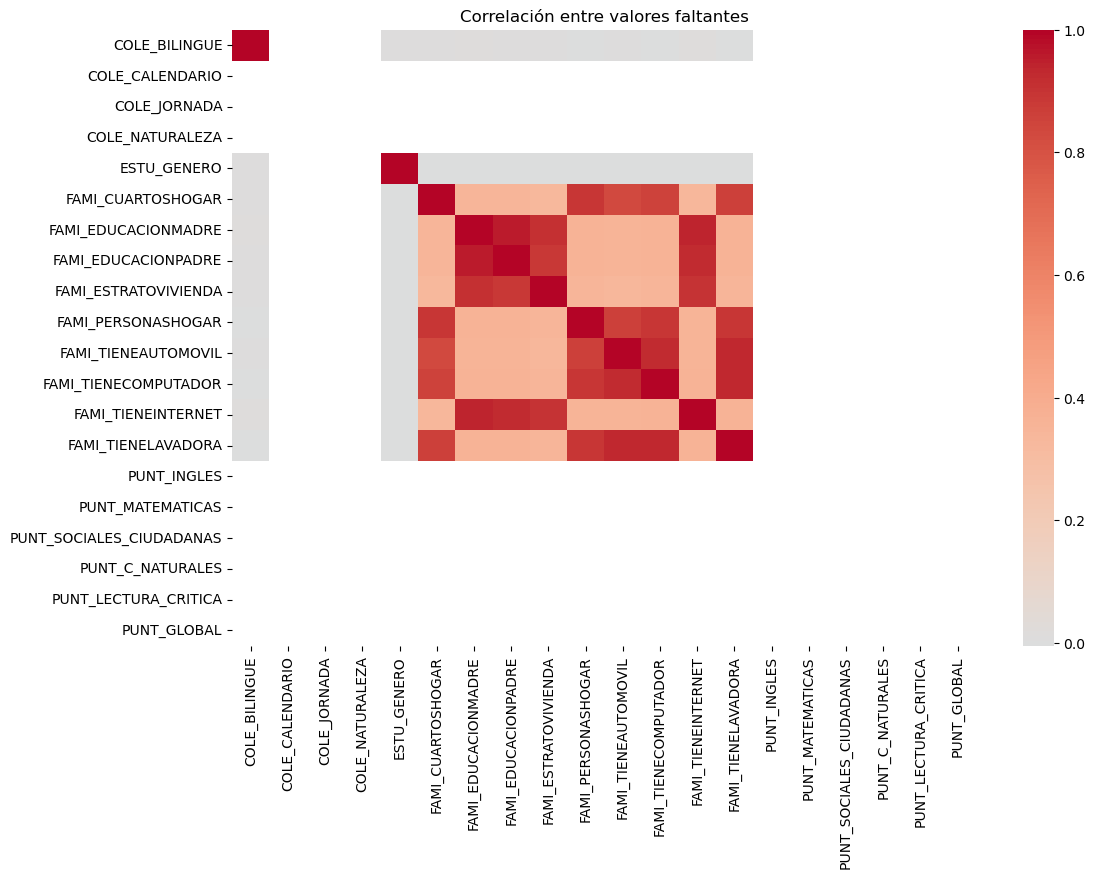

In [15]:
from pyspark.sql.functions import when, col
import seaborn as sns
import matplotlib.pyplot as plt

# Matriz binaria de nulos
df_nulos = df_clean.select([
    when(col(c).isNull(), 1).otherwise(0).alias(c)
    for c in df_clean.columns
])

# Muestra pequeña para no saturar memoria
corr_nulos = df_nulos.sample(0.05, seed=42).toPandas().corr()

# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_nulos,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre valores faltantes")
plt.show()

A partir de la matriz de correlaciones de valores faltantes se puede ver que estos no ocurren de manera completamente aleatoria en todas las variables, ya que hay correlaciones moderadas y altas entre varuables famiiares y socioeconómicas, como en la educacion de los patres y el acceso a computador, internet, disponibilidad de automovil o lavadora en el hogar. Por lo que cuando un estudiante omite informacion relacionada con condiciones en el hogar, tambien es probable que omita informacion en otras variables estructurales similares.

**5.1.1 Imputación**

* La variable ESTU_GENERO y PUNT_INGLES poseen una cantidad de datos faltantes muy inferior al 1%, por lo que se depurarán dichos registros.

* Las variables relacionadas con condiciones estructurales vamos a dejarlas por su peso porcentual, la imputación se hara por medio de crear una nueva categoria llamada "SIN" representando a Sin Información. De igual manera con COLE_BILINGUE que es la variable que mas reporta proporción de datos faltantes, teniendo mas de 125 mil registros, esta imputación se hará con el fin de mantener información y posible analisis futuro al no reporta.

In [16]:
df_clean = df_clean.filter(
    col("ESTU_GENERO").isNotNull() &
    col("PUNT_INGLES").isNotNull()
)

In [17]:
variables_fill = [
    "COLE_BILINGUE",
    "FAMI_CUARTOSHOGAR",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_PERSONASHOGAR",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENELAVADORA"
]

df_clean = df_clean.fillna(
    "SIN",
    subset=variables_fill
)

Comprobamos la imputación y depuración

In [18]:
print("Número de registros:", df_clean.count())

Número de registros: 924616


In [19]:
total_filas = df_clean.count()

resultado_nulos = df_clean.select([
    
    count(when(col(c).isNull(), c)).alias(c)
    
    for c in df_clean.columns

]).toPandas().T.reset_index()

resultado_nulos.columns = ["Variable", "Nulos"]

resultado_nulos["Porcentaje_Nulos"] = round(
    (resultado_nulos["Nulos"] / total_filas) * 100,
    2
)

resultado_nulos

,Variable,Nulos,Porcentaje_Nulos
0,COLE_BILINGUE,0,0.0
1,COLE_CALENDARIO,0,0.0
2,COLE_JORNADA,0,0.0
3,COLE_NATURALEZA,0,0.0
4,ESTU_GENERO,0,0.0
5,FAMI_CUARTOSHOGAR,0,0.0
6,FAMI_EDUCACIONMADRE,0,0.0
7,FAMI_EDUCACIONPADRE,0,0.0
8,FAMI_ESTRATOVIVIENDA,0,0.0
9,FAMI_PERSONASHOGAR,0,0.0


### 5.2 Calidad de variables cuantitativas

In [20]:
variables_cuantitativas = [
    "PUNT_INGLES",
    "PUNT_MATEMATICAS",
    "PUNT_SOCIALES_CIUDADANAS",
    "PUNT_C_NATURALES",
    "PUNT_LECTURA_CRITICA",
    "PUNT_GLOBAL"
]

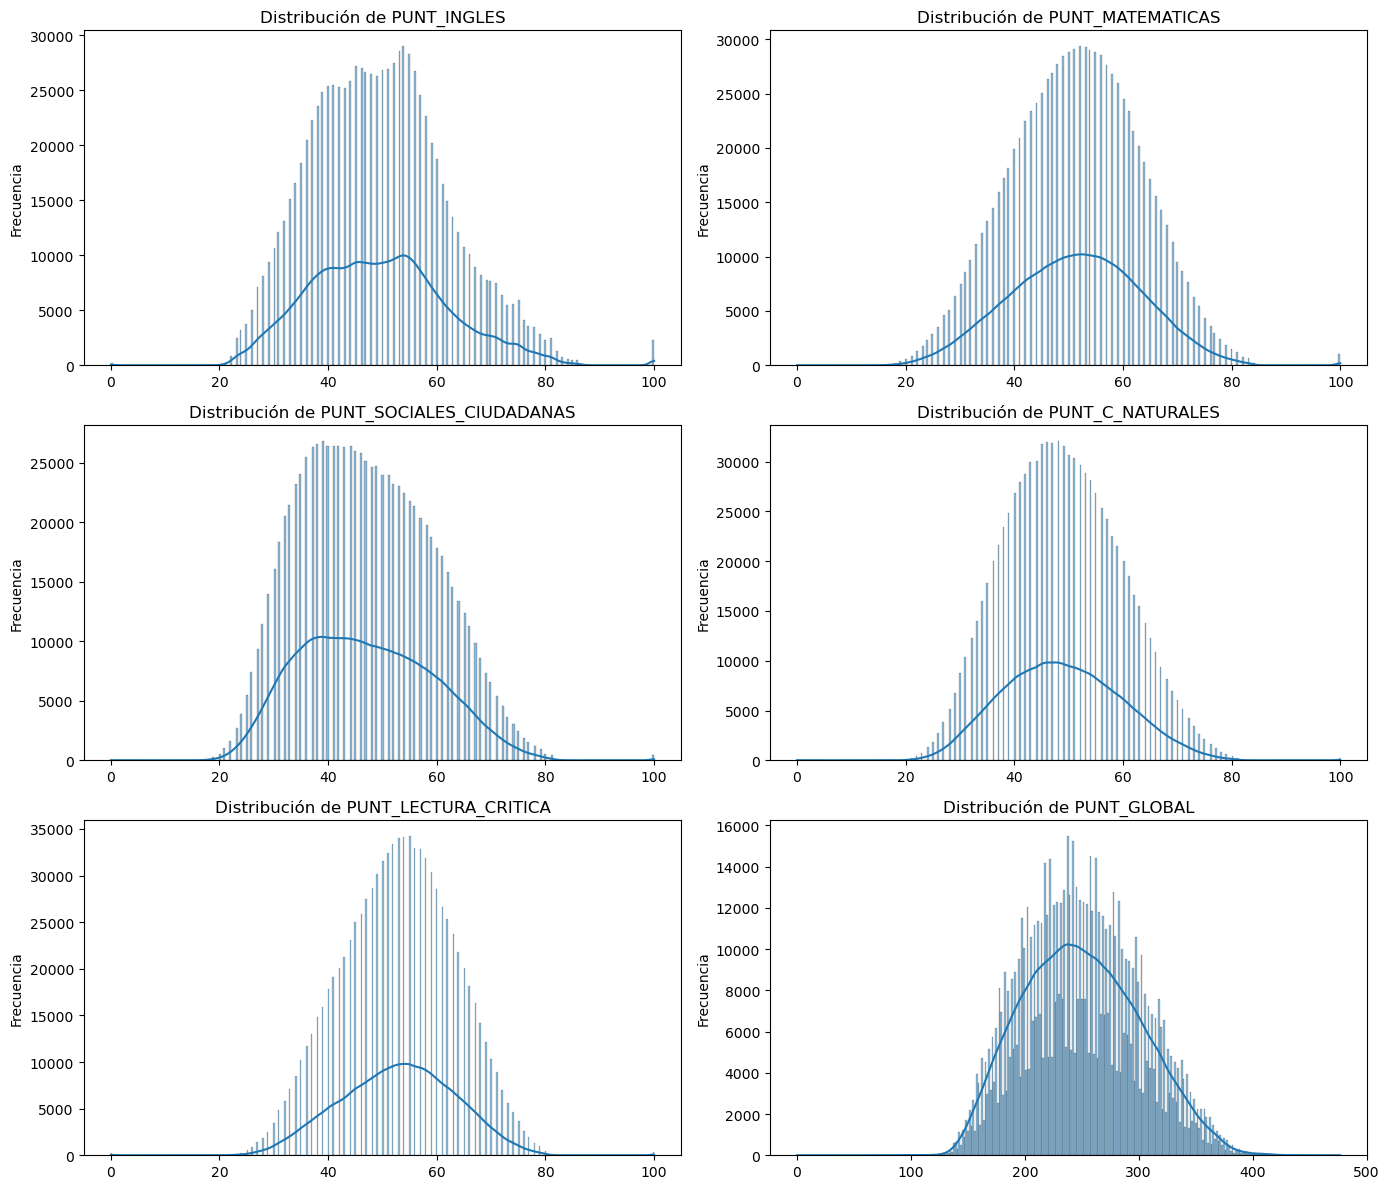

In [21]:
df_plot = df_clean.select(variables_cuantitativas).toPandas()

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(variables_cuantitativas):
    
    sns.histplot(
        df_plot[var],
        kde=True,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribución de {var}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Los puntajes academicos se ven relativamente cercanos a una distribucion normal, sobre todo en matematicas, ciencias naturales y lectura critica. La mayoria de los estudiantes se ubica en niceles intermedios de desempeño y los valores atipicos no son tan frecuentes.

Las variables de ingles y ciencias ciudadanas tienen una pequeña asimetria positiva, y el puntaje global se puede observar una concentracion predominante en los 200 y 300 puntos.

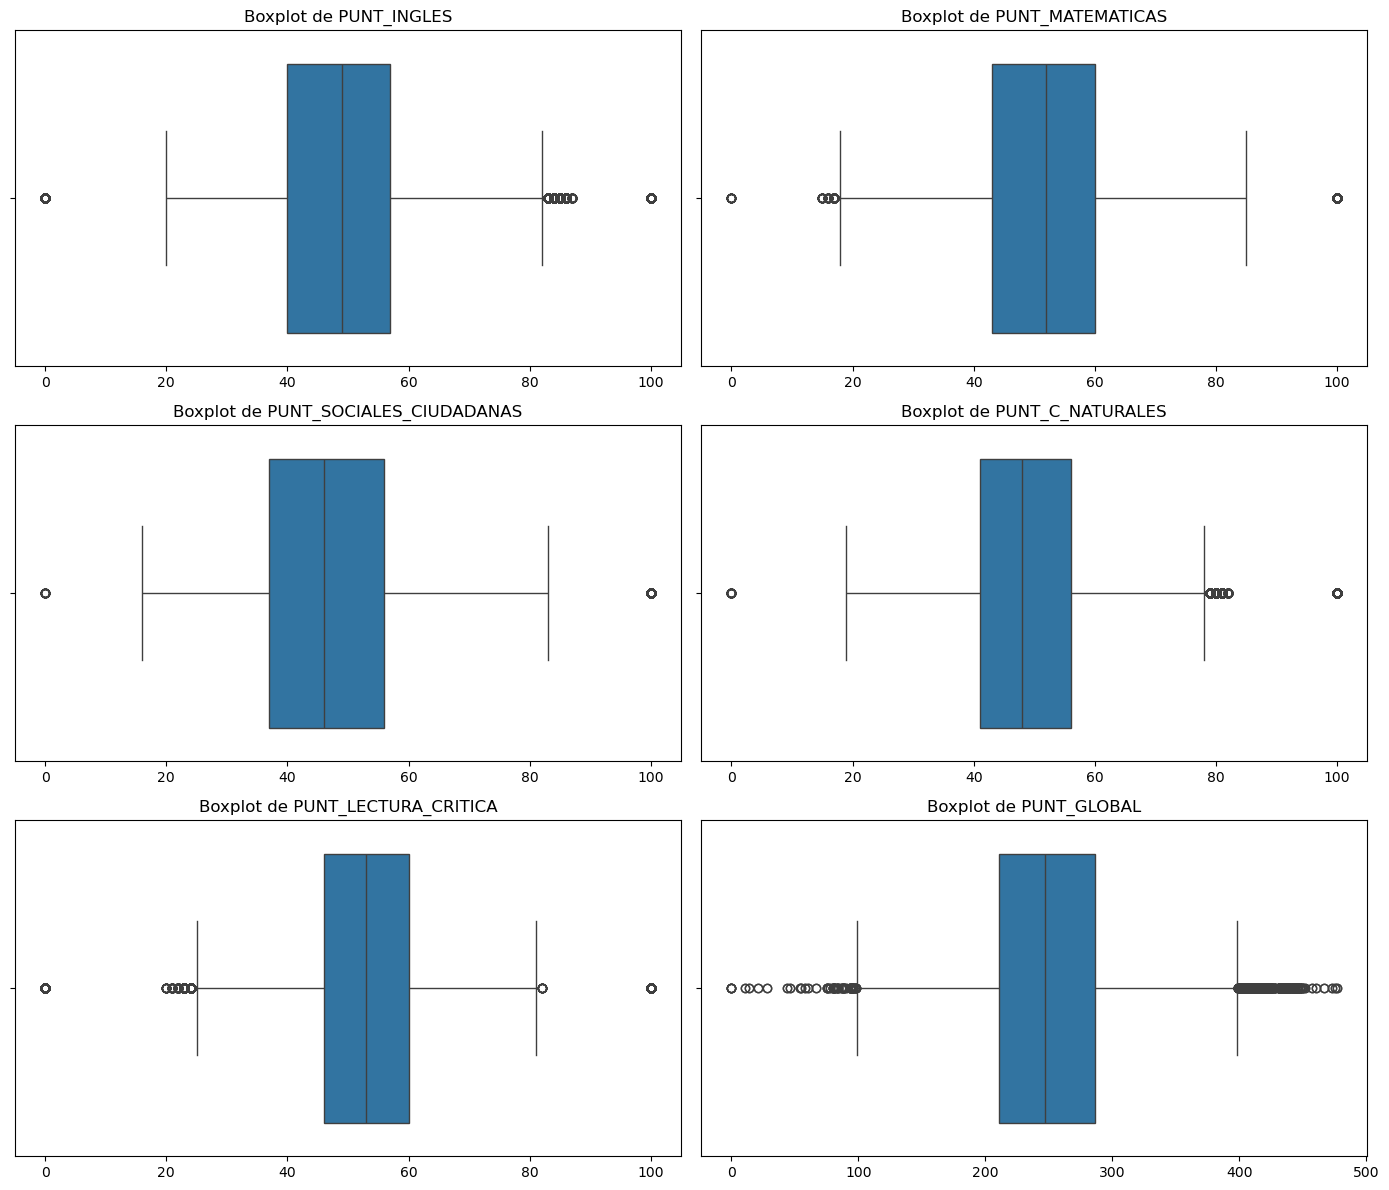

In [22]:
df_plot = df_clean.select(variables_cuantitativas).toPandas()

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes = axes.flatten()

for i, var in enumerate(variables_cuantitativas):
    
    sns.boxplot(
        x=df_plot[var],
        ax=axes[i]
    )
    
    axes[i].set_title(f"Boxplot de {var}")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

Como se vio en las distribuciones, los puntajes academicos para todos se concentran en rangos medios. Los valores atipicos se presentan en todas las areas, donde en ingles y ciencias naturales hay mas evidencia de atipicos de estudiantes con altos puntajes superiores al promedio. Para matematicas y lectura critica aparece el caso contrario, hay mas estudiantes de valores atipicos con resultados menores al promedio, y en sociales y ciudadanas no hay tanta representacion de valores atipicos.

En cuanto al puntaje global, es el que contiene mayor presencia de datos atipicos, sin embargo presentan mas casos y estan relativamente mas concetrados, lo cual tiene sentido con la estabilidad presente en las areas de estudio evaluadas.

### 5.3 Calidad variables cualitativas

In [23]:
variables_cualitativas = [
    "COLE_BILINGUE",
    "COLE_CALENDARIO",
    "COLE_JORNADA",
    "COLE_NATURALEZA",
    "ESTU_GENERO",
    "FAMI_CUARTOSHOGAR",
    "FAMI_EDUCACIONMADRE",
    "FAMI_EDUCACIONPADRE",
    "FAMI_ESTRATOVIVIENDA",
    "FAMI_PERSONASHOGAR",
    "FAMI_TIENEAUTOMOVIL",
    "FAMI_TIENECOMPUTADOR",
    "FAMI_TIENEINTERNET",
    "FAMI_TIENELAVADORA"
]

In [24]:
from pyspark.sql.functions import col, when

df_clean = df_clean.withColumn(
    "FAMI_EDUCACIONMADRE",
    
    when(col("FAMI_EDUCACIONMADRE") == "Primaria incompleta", "Primaria inc.")
    .when(col("FAMI_EDUCACIONMADRE") == "Primaria completa", "Primaria comp.")
    .when(col("FAMI_EDUCACIONMADRE") == "Secundaria (Bachillerato) incompleta", "Bachillerato inc.")
    .when(col("FAMI_EDUCACIONMADRE") == "Secundaria (Bachillerato) completa", "Bachillerato comp.")
    .when(col("FAMI_EDUCACIONMADRE") == "Técnica o tecnológica incompleta", "Técnica/Tec. inc.")
    .when(col("FAMI_EDUCACIONMADRE") == "Técnica o tecnológica completa", "Técnica/Tec. comp.")
    .when(col("FAMI_EDUCACIONMADRE") == "Educación profesional incompleta", "Profesional inc.")
    .when(col("FAMI_EDUCACIONMADRE") == "Educación profesional completa", "Profesional comp.")
    .when(col("FAMI_EDUCACIONMADRE") == "No Aplica", "No aplica")
    .otherwise(col("FAMI_EDUCACIONMADRE"))
)

df_clean = df_clean.withColumn(
    "FAMI_EDUCACIONPADRE",
    
    when(col("FAMI_EDUCACIONPADRE") == "Primaria incompleta", "Primaria inc.")
    .when(col("FAMI_EDUCACIONPADRE") == "Primaria completa", "Primaria comp.")
    .when(col("FAMI_EDUCACIONPADRE") == "Secundaria (Bachillerato) incompleta", "Bachillerato inc.")
    .when(col("FAMI_EDUCACIONPADRE") == "Secundaria (Bachillerato) completa", "Bachillerato comp.")
    .when(col("FAMI_EDUCACIONPADRE") == "Técnica o tecnológica incompleta", "Técnica/Tec. inc.")
    .when(col("FAMI_EDUCACIONPADRE") == "Técnica o tecnológica completa", "Técnica/Tec. comp.")
    .when(col("FAMI_EDUCACIONPADRE") == "Educación profesional incompleta", "Profesional inc.")
    .when(col("FAMI_EDUCACIONPADRE") == "Educación profesional completa", "Profesional comp.")
    .when(col("FAMI_EDUCACIONPADRE") == "No Aplica", "No aplica")
    .otherwise(col("FAMI_EDUCACIONPADRE"))
)

C:\Users\luisa\AppData\Local\Temp\ipykernel_19444\1905922440.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\luisa\AppData\Local\Temp\ipykernel_19444\1905922440.py:13: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\luisa\AppData\Local\Temp\ipykernel_19444\1905922440.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\luisa\AppData\Local\Temp\ipykernel_19444\1905922440.py:13: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.barplot(
C:\Users\luisa\AppData\Local\Temp\ipykernel_19444\1905922440.py:13: FutureWarning: 

Passing `palette` without a

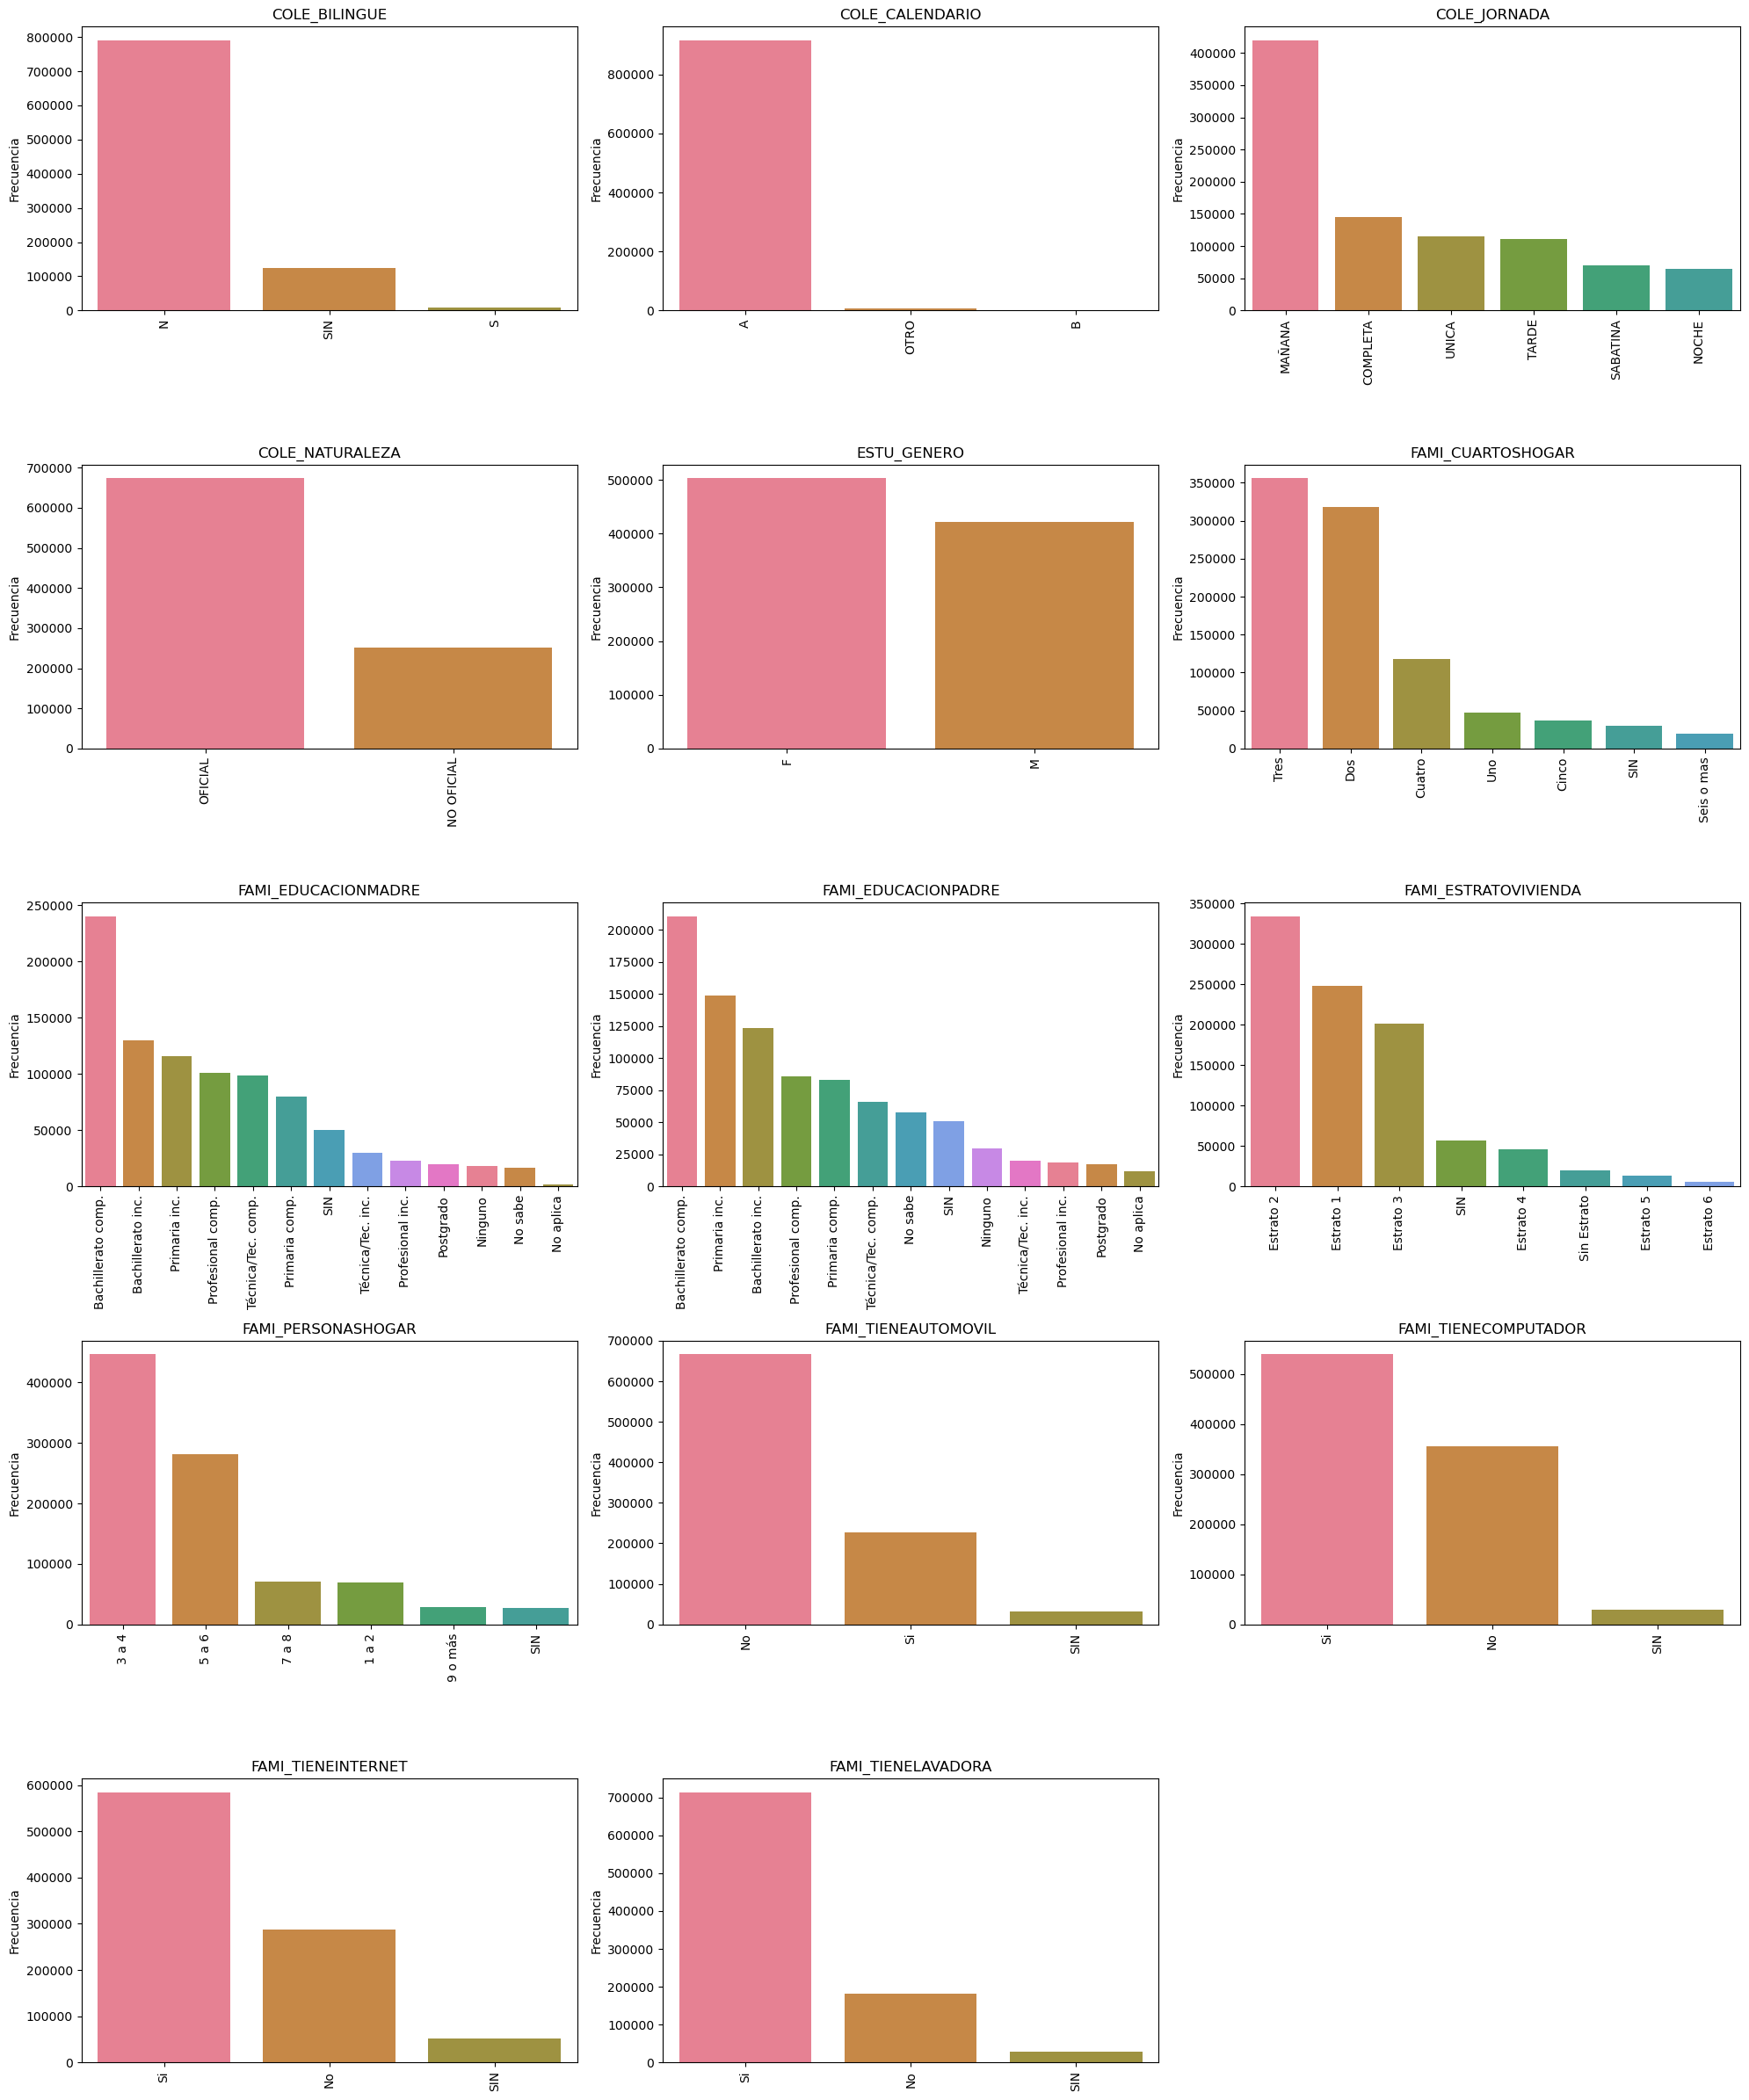

In [25]:
df_cat = df_clean.select(variables_cualitativas).toPandas()

fig, axes = plt.subplots(5, 3, figsize=(20, 24))

axes = axes.flatten()

palette = sns.color_palette("husl", 10)

for i, var in enumerate(variables_cualitativas):
    
    conteos = df_cat[var].value_counts()
    
    sns.barplot(
        x=conteos.index,
        y=conteos.values,
        ax=axes[i],
        palette=palette
    )
    
    axes[i].set_title(var)
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

if len(variables_cualitativas) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

Con las variables categoricas se puede observar una concentracion de estudiantes que provienen de colegios oficiales, no bilingues y de calendario A, en una jornada de la mañana. La distribucion de genero se encuentra relativamente equilibrada con mayor presencia femenina. 

Las variables familiares se observa un predominio de estratos socioeconomicos 1, 2 y 3, tambien que la mayoria de hogares se conforma por 3 y 6 personas, y los noveles educativos mas frecuentes en los padres y madres corresponden a primaria y bachillerato.

En cuanto a variables mas estructurales, se puede ver que la mayoria de estudiantes reportan tener acceso a internet y computador en el hogar, pero hay una parte importante sin acceso a esos recursos.

## 6. Transformaciones analíticas

**¿Existe diferencia en el puntaje global según acceso a internet?**

In [26]:
from pyspark.sql.functions import avg

df_clean.groupBy("FAMI_TIENEINTERNET") \
    .agg(
        avg("PUNT_GLOBAL").alias("PROMEDIO_PUNT_GLOBAL")
    ) \
    .show()

+------------------+--------------------+
|FAMI_TIENEINTERNET|PROMEDIO_PUNT_GLOBAL|
+------------------+--------------------+
|               SIN|   223.7226461133274|
|                No|   233.2347631994326|
|                Si|  260.40787765310444|
+------------------+--------------------+



Los estudiantes que reportan tener internet en sus hogares tienen un aproximado de 30 puntos más en el promedio global.

**¿Cómo cambia el desempeño según estrato?**

In [27]:
from pyspark.sql.functions import avg, stddev

df_clean.groupBy("FAMI_ESTRATOVIVIENDA") \
    .agg(
        avg("PUNT_GLOBAL").alias("PROMEDIO"),
        stddev("PUNT_GLOBAL").alias("DESVIACION")
    ) \
    .show()

+--------------------+------------------+------------------+
|FAMI_ESTRATOVIVIENDA|          PROMEDIO|        DESVIACION|
+--------------------+------------------+------------------+
|           Estrato 3|264.01245935545455|51.139748215433855|
|           Estrato 2|252.01239056594747| 47.74050346261682|
|                 SIN|224.68693115929298|  50.4879157537216|
|           Estrato 6| 256.6857433118862| 71.54921062455497|
|           Estrato 4| 274.1185433088203| 60.85980625513475|
|         Sin Estrato|210.59744408945687| 44.97249480526258|
|           Estrato 1|238.79410246899644| 46.16008725057301|
|           Estrato 5| 270.3459637561779| 66.17023451789073|
+--------------------+------------------+------------------+



La relacion entre estrato socieconomico y desempeño academico es proporcional en el aumento del promedio del puntaje global, sin embargo hay que resaltar que los estratos 4 y 5 son los que presentan mejor promedio, mientras que el estrato 6 es considerablemente menor.

| Estrato | TOP |
|:---:|:---:|
| Estrato 4 | 1 |
| Estrato 5 | 2 |
| Estrato 3 | 3 |
| Estrato 6 | 4 |
| Estrato 2 | 5 |
| Estrato 1 | 6 |
| Sin informacion | 7 |
| Sin estrato | 8 |

**¿Cuántos estudiantes tienen desempeño sobresaliente? (Teniendo en cuenta que 320 correspondia aproximadamente al percentil 90)**


In [28]:
df_alto = df_clean.filter(
    col("PUNT_GLOBAL") >= 320
)

print("Estudiantes sobresalientes:", df_alto.count())

Estudiantes sobresalientes: 92506


**¿El acceso a la tecnologia fue un factor que afecto el desempeño?**

In [29]:
df_clean = df_clean.withColumn(
    "ACCESO_TECNOLOGICO",
    
    when(
        (col("FAMI_TIENEINTERNET") == "Si") &
        (col("FAMI_TIENECOMPUTADOR") == "Si"),
        "Alto acceso"
    ).otherwise("Bajo acceso")
)

df_clean.groupBy("ACCESO_TECNOLOGICO") \
    .agg(avg("PUNT_GLOBAL").alias("PROMEDIO_PUNT_GLOBAL")) \
    .show()

+------------------+--------------------+
|ACCESO_TECNOLOGICO|PROMEDIO_PUNT_GLOBAL|
+------------------+--------------------+
|       Alto acceso|   265.0975584064465|
|       Bajo acceso|  235.14383383447424|
+------------------+--------------------+



Hay una diferencia en tener acceso a la tecnologia, de 30 puntos a favor para alto acceso, comparando el promedio global.

## 7. Conclusiones

1. En analisis poblacional general, podemos ver que los estudiantes en su mayoria provienen de estratos socioeconomicos bajos y medios, con padres de familia que tienen niveles escolares hasta primaria y bachillerato, por lo que muchos de los estudiantes reflejan una posible desigualdad economica que puede llegar a influir directamente en oportunidades de aprendizaje y por ende en los resultados obtenidos en puntaje global, ya que los estudiantes con mejor promedio por estrato se encontraban por encima del estrato 3.

2. Hay que tener en cuenta que en esta base de datos de estudiantes se esta teniendo en cuenta el area urbana, por lo que es importante destacar que hay una brecha aproximada de treinta puntos en promedio entre los estudiantes que tienen acceso a tecnologia (internet y computador). Ademas, es mas comun ver que en areas rurales no hay acceso a tecnologia, y para el año 2019 la tecnologia en areas urbanas era mas comun, por lo que estas personas que no cuentan con acceso a tecnologia posiblemente vivan en una condicion mas vulnerable.

3. Para el analisis que se desarrollara en la clasificacion, es obtimo tomar en cuenta la diferenciacion a partir del puntaje 320 que hace referencia al percentil 90 en el Saber 11 del 2019 (aproximadamente para las dos evaluaciones del año), por lo que la clasificacion se puede evaluar por estudiantes sobresalientes = 1, y el resto 0, para evaluar la clasificacion de dichos estudiantes. 

4. En cuanto a las variables a usar, como se observaron sus distribuciones parecen aproximarse a una distribucion normal en todas las areas y el puntaje global, se puede hacer un escalamiento para controlar los datos atipicos. Para las variables cualitativas, que son un total de 14, se podria evaluar el uso de one-hot-encoding para capturar el efecto de cada categoria, o en su defecto se podria hacer un MCA para reducir dimensionalidad y resumir la informacion que pueden contener dichas variables.

**Vamos a guardar la base de datos para usarla en el Bloque 2**

In [35]:
df_clean_pd = df_clean.toPandas()

df_clean_pd.to_csv(
    r"C:\Users\luisa\OneDrive\Documentos\proyecto_final_JosuePedraza\datos\df_clean_icfes.csv",
    index=False,
    encoding="utf-8-sig"
)